## Import Libraries and Load data

In [1]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH= './../data'

In [3]:
main_df = pd.read_csv(os.path.join(DATA_PATH,'CNA_SV.csv'))
main_df.head()

,Unnamed: 0,9-Sep_SV,A2BP1_SV,AASDH_SV,AATF_SV,AATK_SV,AATK-AS1_SV,ABCA1_SV,ABCA12_SV,ABCA13_SV,...,TSC2_CNA,TSHR_CNA,U2AF1_CNA,VHL_CNA,WT1_CNA,XPO1_CNA,ZRSR2_CNA,SEX,AGE_AT_SEQ_REPORT,CANCER_TYPE
0,GENIE-DFCI-000024-4434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,87,Esophagogastric Cancer
1,GENIE-DFCI-000027-10441,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,Female,74,Soft Tissue Sarcoma
2,GENIE-DFCI-000029-10065,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,Male,63,Renal Cell Carcinoma
3,GENIE-DFCI-000029-526237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,Male,65,Renal Cell Carcinoma
4,GENIE-DFCI-000035-11184,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Female,67,CNS Cancer


## Data Preprocessing

In [4]:
df_CNA_SV = main_df[main_df['CANCER_TYPE'] != 'Cancer of Unknown Primary']
test_df = main_df[main_df['CANCER_TYPE'] == 'Cancer of Unknown Primary']


# Filter based on cancer types with more than 1000 instances
cancer_count = df_CNA_SV['CANCER_TYPE'].value_counts()
selected_cancer_types = cancer_count[cancer_count.values > 1000].index.to_list()
df_CNA_SV = df_CNA_SV[df_CNA_SV['CANCER_TYPE'].isin(selected_cancer_types)].reset_index(drop=True)

# Drop columns with zero variation
zero_variation_col = []
for col in df_CNA_SV.columns:
    if len(df_CNA_SV[col].unique()) <= 1:
        zero_variation_col.append(col)


df = df_CNA_SV.copy()
df=df.drop(['Unnamed: 0']+zero_variation_col,axis=1).reset_index(drop=True)

In [5]:
## Label encode cancer types
label_encoder_cancer = LabelEncoder()
df['CANCER_TYPE'] = label_encoder_cancer.fit_transform(df['CANCER_TYPE'])

In [7]:
#Remove low correlated features
import pickle

with open(os.path.join(DATA_PATH,'specific_column_corr.pickle'), 'rb') as handle:
    specific_column_corr_loaded = pickle.load(handle)

unselected_features=[col for col in df.columns if col not in specific_column_corr_loaded.index.to_list()]

df=df.drop(unselected_features,axis=1).reset_index(drop=True)
df.shape

(16493, 207)

In [8]:
X_test =test_df.drop(['Unnamed: 0','CANCER_TYPE'] + zero_variation_col+unselected_features,axis=1).reset_index(drop=True)
X_test.shape

(821, 206)

In [9]:
# Split the data into features and target
X = df.drop(columns=['CANCER_TYPE'])
y = df['CANCER_TYPE']

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [10]:
#Data transformation

label_encoder_sex = LabelEncoder()
X_train['SEX'] = label_encoder_sex.fit_transform(X_train[['SEX']])

scaler = StandardScaler()
X_train['AGE_AT_SEQ_REPORT'] = scaler.fit_transform(X_train[['AGE_AT_SEQ_REPORT']])

X_val['SEX'] = label_encoder_sex.transform(X_val['SEX'])
X_val['AGE_AT_SEQ_REPORT'] = scaler.transform(X_val[['AGE_AT_SEQ_REPORT']])


X_test['SEX'] = label_encoder_sex.transform(X_test['SEX'])
X_test['AGE_AT_SEQ_REPORT'] = scaler.transform(X_test[['AGE_AT_SEQ_REPORT']])

/home/afiibnat/miniconda3/envs/Ls_env/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [11]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
#test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
#test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Model Training

In [12]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model initialization
input_dim = X_train.shape[1]
output_dim = len(df['CANCER_TYPE'].unique())

In [13]:
import torch.nn.functional as F

class DeepCNA(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DeepCNA, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128) 
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.35)
    
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x



model = DeepCNA(input_dim, output_dim).to(device)

In [14]:
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, patience=5, max_epochs=100):
    train_losses = []
    val_losses = []
    best_val_loss = np.inf
    epochs_no_improve = 0
    best_model = None
    
    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
        
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        
        print(f'Epoch [{epoch+1}/{max_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model = model
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping after {epoch+1} epochs.')
                break
        
        scheduler.step()
    
    return best_model, train_losses, val_losses




In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Train the model with early stopping
best_model, train_losses, val_losses = train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, patience=30, max_epochs=100)

Epoch [1/100], Train Loss: 1.4355, Val Loss: 1.0857
Epoch [2/100], Train Loss: 1.0916, Val Loss: 0.9702
Epoch [3/100], Train Loss: 1.0090, Val Loss: 0.9334
Epoch [4/100], Train Loss: 0.9704, Val Loss: 0.9305
Epoch [5/100], Train Loss: 0.9510, Val Loss: 0.9179
Epoch [6/100], Train Loss: 0.9240, Val Loss: 0.9168
Epoch [7/100], Train Loss: 0.9135, Val Loss: 0.9174
Epoch [8/100], Train Loss: 0.8817, Val Loss: 0.9093
Epoch [9/100], Train Loss: 0.8747, Val Loss: 0.9070
Epoch [10/100], Train Loss: 0.8653, Val Loss: 0.9049
Epoch [11/100], Train Loss: 0.8611, Val Loss: 0.9008
Epoch [12/100], Train Loss: 0.8593, Val Loss: 0.9012
Epoch [13/100], Train Loss: 0.8564, Val Loss: 0.9056
Epoch [14/100], Train Loss: 0.8573, Val Loss: 0.9071
Epoch [15/100], Train Loss: 0.8501, Val Loss: 0.8974
Epoch [16/100], Train Loss: 0.8478, Val Loss: 0.9019
Epoch [17/100], Train Loss: 0.8441, Val Loss: 0.8983
Epoch [18/100], Train Loss: 0.8520, Val Loss: 0.8986
Epoch [19/100], Train Loss: 0.8516, Val Loss: 0.8992
Ep

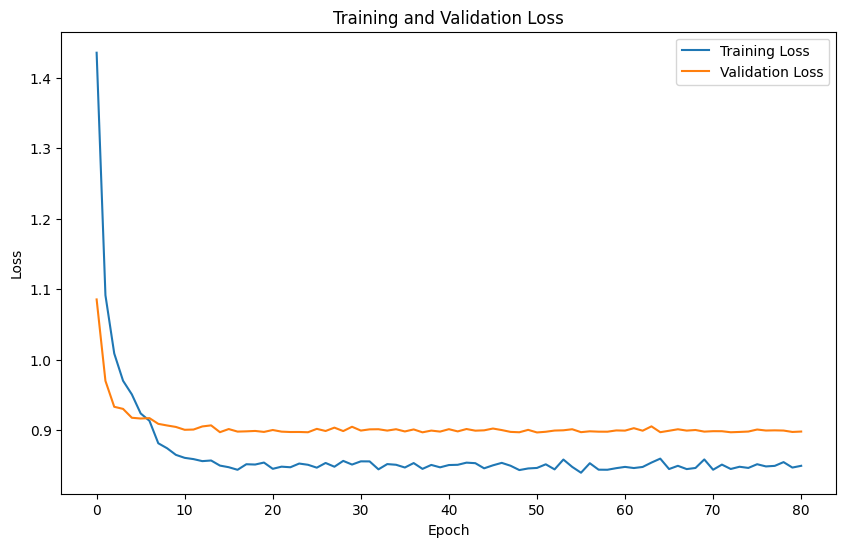

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
# plt.savefig("./data/training_validation_loss_right_fit.png",bbox_inches = 'tight')
plt.show()

In [17]:
# Evaluation mode
best_model.eval()

# Function to calculate accuracy
def calculate_accuracy(loader, model):
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

train_accuracy = calculate_accuracy(train_loader, best_model)
test_accuracy = calculate_accuracy(val_loader, best_model)

print(f'Train Accuracy: {train_accuracy:.2f}%')
print(f'Validation Accuracy: {test_accuracy:.2f}%')


Train Accuracy: 74.34%
Validation Accuracy: 67.32%


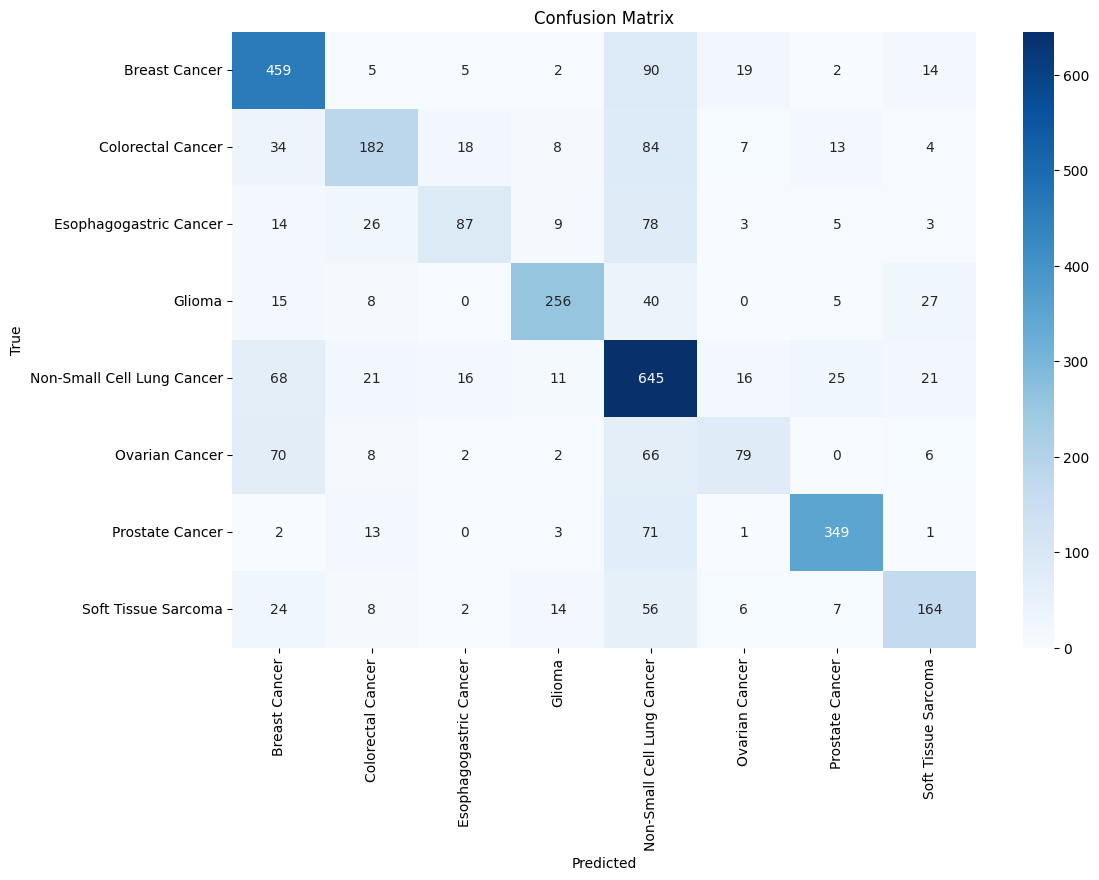

                            precision    recall  f1-score   support

             Breast Cancer       0.67      0.77      0.72       596
         Colorectal Cancer       0.67      0.52      0.59       350
    Esophagogastric Cancer       0.67      0.39      0.49       225
                    Glioma       0.84      0.73      0.78       351
Non-Small Cell Lung Cancer       0.57      0.78      0.66       823
            Ovarian Cancer       0.60      0.34      0.43       233
           Prostate Cancer       0.86      0.79      0.83       440
       Soft Tissue Sarcoma       0.68      0.58      0.63       281

                  accuracy                           0.67      3299
                 macro avg       0.70      0.61      0.64      3299
              weighted avg       0.68      0.67      0.67      3299



In [18]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_val_pred = []
y_val_true = []

best_model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        y_val_pred.extend(predicted.cpu().numpy())
        y_val_true.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_cancer.classes_, yticklabels=label_encoder_cancer.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
# plt.savefig("./data/confusion_matrix_right_fit.png",bbox_inches = 'tight')
plt.show()

# Classification Report
print(classification_report(y_val_true, y_val_pred, target_names=label_encoder_cancer.classes_))
